In [17]:
##########################################################################
import os

# set the environment variable to control the number of threads
# NEEDS TO BE DONE BEFORE CCL IS IMPORTED
original_omp_num_threads = os.environ.get('OMP_NUM_THREADS', None)
os.environ['OMP_NUM_THREADS'] = '1'


# cosmology
import pyccl as ccl
#from astropy.io import fits
import yaml
#import sacc
import time

# Generic
import pandas as pd
import numpy as np
import scipy
from itertools import islice, cycle
import math
import sys
from scipy.integrate import odeint
#from joblib import Parallel, delayed
import itertools
from importlib import reload
from functools import lru_cache
import scipy.integrate
#import baccoemu
import subprocess
import multiprocessing


# Generate data sets
#from sklearn.datasets import make_blobs
#import sklearn
#print(sklearn.__version__) # should be 1.3.2

# PCA
#from sklearn.preprocessing import StandardScaler
#from sklearn.decomposition import PCA

# SRD Binning
import srd_redshift_distributions as srd
import binning

# Data Visualization
import matplotlib.pyplot as plt
from tabulate import tabulate
import matplotlib.patches as mpatches
import matplotlib
#import seaborn as sns

# MCMC
import emcee
import matplotlib.pyplot as plt
from scipy.optimize import minimize
#import corner
from IPython.display import display, Math
from multiprocessing import Pool, cpu_count
#from tqdm import tqdm
import gc

# Profiling
import cProfile
import pstats
from IPython.display import HTML

# nDGP NL and lin Pk
from nDGPemu import BoostPredictor

# f(R) emu (eMANTIS)
from emantis import FofrBoost

# Initialise and emulator instance.
emu_fR = FofrBoost()

In [18]:
from LikelihoodFuncts_PCADR_muSigma_minimal import *

Loading model and related data


In [19]:
# Define cosmology
cosmo_universe = ccl.Cosmology(Omega_c = 0.269619, 
                          Omega_b = 0.050041,
                          h = 0.6688,
                          n_s = 0.9626,
                          A_s = 2.092e-9)


In [20]:
# GET F(R) LINEAR POWER SPECTRUM, fiducial
##########################
idx_mdom = 0
a_solver = np.linspace(1/50,1.1,50)
k_solver = np.logspace(-5,4,200)

Soln = odeint(solverGrowth_nDGP, [a_solver[0], (E(cosmo_universe, a_solver[0])*a_solver[0]**3)], a_solver,\
              args=(cosmo_universe,[0,0,0,0,0]), mxstep=int(1e4))

Delta_GR = Soln.T[0]/Soln.T[0][idx_mdom]

Delta = []
for i in range(len(k_solver)):
    Soln = odeint(solverGrowth_fR, [a_solver[0], (E(cosmo_universe, a_solver[0])*a_solver[0]**3)], a_solver, \
                  args=(cosmo_universe,[0,1e-4,0,0,0], k_solver[i]), mxstep=int(1e4))
    
    Delta_i = Soln.T[0]
    Delta.append(Delta_i/Delta_i[idx_mdom])

Delta = np.array(Delta)

# Get Pk linear in GR

interp_fR_Pk = scipy.interpolate.RegularGridInterpolator((k_solver,a_solver), (Delta / Delta_GR)**2,bounds_error=False, fill_value=1.0)
##########################

In [21]:
# Define the redshift interval and forecast years
redshift_range = np.linspace(0.01, 3.5, 500)
forecast_years = ["1", "10"]  # Assuming integers are appropriate

# Create a dictionary to store the redshift distributions
# for each forecast year and galaxy sample
redshift_distribution = {
    "sources": {},
    "lenses": {}
}

for year in forecast_years:
    source_dist = srd.SRDRedshiftDistributions(redshift_range, 
                                               galaxy_sample="source_sample",
                                               forecast_year=year)
    lens_dist = srd.SRDRedshiftDistributions(redshift_range, 
                                             galaxy_sample="lens_sample",
                                             forecast_year=year)

    redshift_distribution["sources"][year] = source_dist.get_redshift_distribution(normalised=True,
                                                                                   save_file=False)
    redshift_distribution["lenses"][year] = lens_dist.get_redshift_distribution(normalised=True,
                                                                                save_file=False)

# Uncomment to check if the dictionary is populated correctly
# print(redshift_distribution["sources"].keys())


bins = {
    "sources": {},
    "lenses": {}
}

# Perform the binning procedure
for year in forecast_years:
    bins["sources"][year] = binning.Binning(redshift_range, 
                                            redshift_distribution["sources"][year],
                                            year).source_bins(normalised=True,
                                                              save_file=False)
    bins["lenses"][year] = binning.Binning(redshift_range, 
                                           redshift_distribution["lenses"][year],
                                           year).lens_bins(normalised=True,
                                                           save_file=False)


#(5, 256)
Binned_distribution_lens = [list(bins["lenses"]["1"].items())[0][1]]
for i in range(4):
    Binned_distribution_lens = np.append(Binned_distribution_lens,\
               [list(bins["lenses"]["1"].items())[i+1][1]], axis=0)

Binned_distribution_source = [list(bins["sources"]["1"].items())[0][1]]
for i in range(4):
    Binned_distribution_source = np.append(Binned_distribution_source,\
               [list(bins["sources"]["1"].items())[i+1][1]], axis=0)

In [22]:
Bias_distribution_fiducial = np.array([1.562362*np.ones(len(redshift_range)),
                             1.732963*np.ones(len(redshift_range)),
                             1.913252*np.ones(len(redshift_range)),
                             2.100644*np.ones(len(redshift_range)),
                             2.293210*np.ones(len(redshift_range))])


In [23]:
"""Test P(k) objects under the hood"""
P_delta2D_GR_lin_universe = Get_Pk2D_obj_kk_GR_lin(cosmo_universe)
P_delta2D_GR_nl_universe = Get_Pk2D_obj_kk_GR_nl(cosmo_universe)


P_delta2D_nDGP_nl = Get_Pk2D_obj(P_delta2D_GR_nl_universe, interp_fR_Pk,cosmo_universe, [0.2,1e-5,1,0,0],linear=False,gravity_model="nDGP")



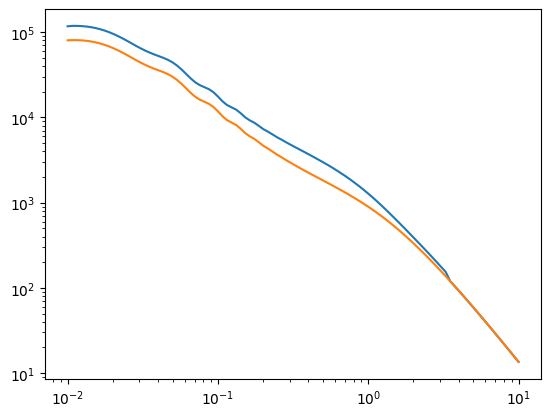

In [26]:
k_arr = np.logspace(-2,1,100)

plt.loglog(k_arr, P_delta2D_nDGP_nl.__call__(k=k_arr, a=1))
plt.loglog(k_arr, P_delta2D_GR_nl_universe.__call__(k=k_arr, a=1))

In [27]:
def testoutputs(Data, cosmo, MGparams, L_ch_inv):

    # Precompute Pk2D objects: GR
    P_delta2D_GR_lin = Get_Pk2D_obj_kk_GR_lin(cosmo)
    P_delta2D_GR_nl = Get_Pk2D_obj_kk_GR_nl(cosmo)

    # Condition on sigma8 (prior)
    k_val = np.logspace(-4, 3, 3000)
    P_k_vals = P_delta2D_GR_lin.__call__(k_val, 1)
    j1_vals = 3 * scipy.special.spherical_jn(1, k_val * 8 / cosmo["h"], derivative=False) / (k_val * 8 / cosmo["h"])
    integrand = k_val**2 * P_k_vals * j1_vals**2
    integral_val = scipy.integrate.trapz(integrand, x=k_val)
    sigma8_val = np.sqrt(integral_val / (2 * np.pi**2))

    if not 0.6083 < sigma8_val < 1.014:
        return -np.inf
        
    #start = time.time()
    # z_fsigma8, fsigma_8_dataset, invcovariance_fsigma8 = data_fsigma8

    # Extract real data vector
    D_data, ell_mockdata, z, Binned_distribution_s,Binned_distribution_l,\
                ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata = Data

    # Do binning
    binned_ell_kk = bin_ell_kk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata, Binned_distribution_s)


    ##########################
    # Precompute Pk2D objects
    P_delta2D_muSigma_kk = Get_Pk2D_obj_kk_musigma(P_delta2D_GR_lin,cosmo, MGparams)
    
    P_delta2D_nDGP_lin = Get_Pk2D_obj(P_delta2D_GR_lin,None,cosmo, MGparams, linear=True, gravity_model="nDGP")
    P_delta2D_nDGP_nl = Get_Pk2D_obj(P_delta2D_GR_nl,None,cosmo, MGparams, linear=False, gravity_model="nDGP")
    
    ########## Get theoretical data vector for single MCMC step - linear , muSigmaparam ##########
    # shape-shape
    D_theory = (np.array(Cell(binned_ell_kk, \
                cosmo, z , Binned_distribution_s,None,None,MGparams,P_delta2D_muSigma_kk,\
                tracer1_type="k", tracer2_type="k")[1])).flatten()
    
    Diff = (D_data - D_theory)
    
    # Find Choleski scaled data vector
    Diff_ch = np.array(np.matmul(L_ch_inv, Diff.T))[0]
    
    ########## GET DATA FOR DIFFERENCE MATRIX ##########
    """MG1: nDGP"""
    # A: find C_ell for non-linear matter power spectrum
    # shape-shape
    B1 = (np.array(Cell(binned_ell_kk, \
                cosmo, z , Binned_distribution_s,None,None,MGparams,P_delta2D_nDGP_nl,\
                tracer1_type="k", tracer2_type="k")[1])).flatten()
       
    # B: find C_ell for linear matter power spectrum
    # shape-shape
    M1 = (np.array(Cell(binned_ell_kk, \
                cosmo, z , Binned_distribution_s,None,None,MGparams,P_delta2D_nDGP_lin,\
                tracer1_type="k", tracer2_type="k")[1])).flatten()

    
    """GR"""

    # A: find C_ell for non-linear matter power spectrum
    # shape-shape 
    B2 = (np.array(Cell(binned_ell_kk, \
                cosmo, z , Binned_distribution_s,None,None,MGparams,P_delta2D_GR_nl,\
                tracer1_type="k", tracer2_type="k")[1])).flatten()
       
    # B: find C_ell for linear matter power spectrum
    # shape-shape
    M2 = (np.array(Cell(binned_ell_kk, \
                cosmo, z , Binned_distribution_s,None,None,MGparams,P_delta2D_GR_lin,\
                tracer1_type="k", tracer2_type="k")[1])).flatten()

    ### COMBINE
    
    B_data =np.array([B1,B2])
    M_data =np.array([M1,M2])

    # EXTRACT PCA MATRIX
    Usvd = findPCA(M_data, B_data, L_ch_inv)

    # Cut data vector (choleski cov. matrix = I)
    Diff_cut = np.matmul(Usvd[len(M_data):], Diff_ch.T)
    
    #print("time = ", time.time() - start)
    
    return binned_ell_kk, B1, M1, B2,M2

In [52]:
npzfile = np.load("Data_storage_GR.npz")

C_ell_data_mock = [npzfile['C_ell_data'][:195],npzfile['ell_data'][:195],npzfile['z'],npzfile['Binned_distribution_source'],\
                    npzfile['Binned_distribution_lens'],20,1478.5,13]

L_choleski_cut_inv = np.matrix(npzfile['L_ch_inv'])

#################

# Get covariance from scratch

covfile = np.genfromtxt("Y1_3x2pt_clusterN_clusterWL_cov")

shear_SRD = np.zeros((705,705))
ell_test_SRD = np.zeros(705)

for i in range(0,covfile.shape[0]):
    shear_SRD[int(covfile[i,0]),int(covfile[i,1])] = covfile[i,8]+covfile[i,9] # non-gauss
    shear_SRD[int(covfile[i,1]),int(covfile[i,0])] = covfile[i,8]+covfile[i,9] # non-gauss
    if int(covfile[i,0]) == int(covfile[i,1]):
        ell_test_SRD[int(covfile[i,0])] = covfile[i,2]

del covfile
SRD_compare = shear_SRD[:540,:540].copy()

idx = 0

bins_SRD = int(len(SRD_compare)/(len(C_ell_data_mock[0])/13))

for j in range(int(len(C_ell_data_mock[0])/13)):
    for i in range(bins_SRD):
        if i >= 13:
            SRD_compare = np.delete(SRD_compare, j*bins_SRD + i - idx, 0)
            SRD_compare = np.delete(SRD_compare, j*bins_SRD + i - idx, 1)
            idx += 1

covariance_uncut = np.matrix(SRD_compare)

L_choleski_inv = np.matrix(np.linalg.inv(np.linalg.cholesky(covariance_uncut[:195,:195])))

#################

binned_ell_kk, B1, M1, B2,M2 = testoutputs(C_ell_data_mock, cosmo_universe, [0.2,1e-5,1,0,0], L_choleski_inv)


In [69]:
covfile = np.genfromtxt("/home/c2042999/PCA_project/Parameter_inference_GR/Y1_3x2pt_clusterN_clusterWL_cov")

shear_SRD = np.zeros((705,705))
ell_test_SRD = np.zeros(705)

for i in range(0,covfile.shape[0]):
    shear_SRD[int(covfile[i,0]),int(covfile[i,1])] = covfile[i,8]+covfile[i,9] # non-gauss
    shear_SRD[int(covfile[i,1]),int(covfile[i,0])] = covfile[i,8]+covfile[i,9] # non-gauss
    if int(covfile[i,0]) == int(covfile[i,1]):
        ell_test_SRD[int(covfile[i,0])] = covfile[i,2]

del covfile
SRD_compare = shear_SRD[:540,:540].copy()

idx = 0


bins_SRD = 20
print("bins_SRD", bins_SRD)
print(int(len(C_ell_data_mock[0])/13))
for j in range(27):
    for i in range(bins_SRD):
        if i >= 13:
            SRD_compare = np.delete(SRD_compare, j*bins_SRD + i - idx, 0)
            SRD_compare = np.delete(SRD_compare, j*bins_SRD + i - idx, 1)
            idx += 1

covariance_uncut = np.matrix(SRD_compare)

Mat_plot_2 = np.linalg.inv(np.linalg.cholesky(covariance_uncut[:195,:195]))

print(Mat_plot_2.shape)

bins_SRD 20
15
(195, 195)


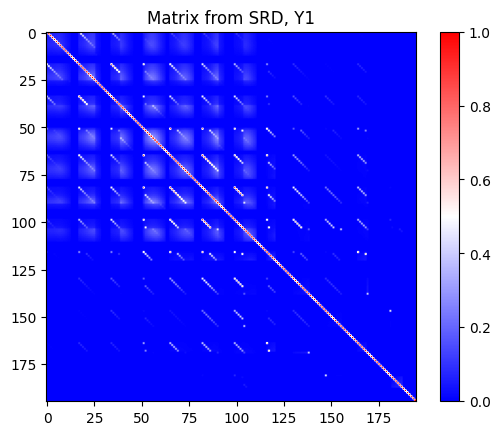

In [59]:
def cov2corr(cov):
    """
    Convert a covariance matrix into a correlation matrix
    input:
        cov: numpy.array with dim:(N,N)
    returns:
        corr: numpy.array with dim:(N,N)
    """
    sig = np.sqrt(cov.diagonal())
    return cov/np.outer(sig, sig)
    
plt.imshow(cov2corr(covariance_uncut), origin='upper',  cmap='bwr')
plt.title("Matrix from SRD, Y1")
plt.colorbar()
plt.show()

In [29]:
print(binned_ell_kk.shape)
print(B1.shape)
print(M1.shape)
print(B2.shape)
print(M2.shape)

(15, 13)
(195,)
(195,)
(195,)
(195,)


15


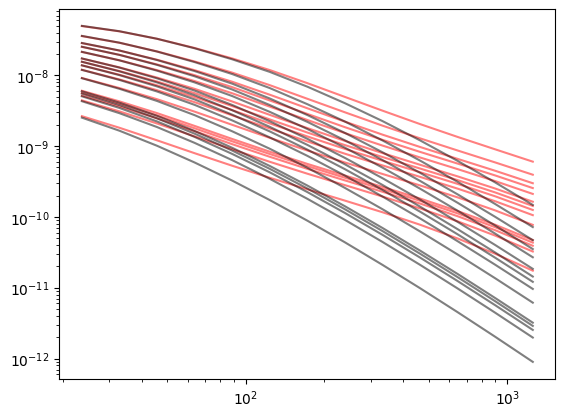

In [40]:
print(len(binned_ell_kk))
for i in range(len(binned_ell_kk)):
    plt.loglog(binned_ell_kk[i], B2[i*13:(i+1)*13], "r", alpha=0.5)
    plt.loglog(binned_ell_kk[i], M2[i*13:(i+1)*13], "k", alpha=0.5)

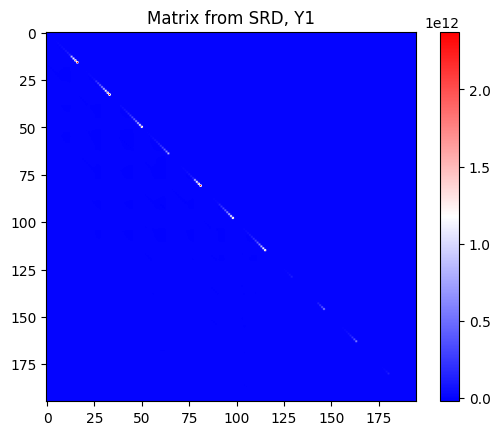

In [41]:
plt.imshow((L_choleski_inv), origin='upper',  cmap='bwr')
plt.title("Matrix from SRD, Y1")
plt.colorbar()
plt.show()

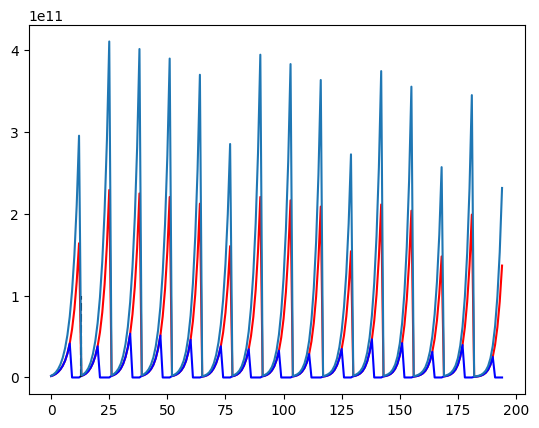

In [72]:
plt.plot(np.diag(Mat_plot_2), "r")
plt.plot(np.diag(L_choleski_cut_inv[:195,:195]), "b")

plt.plot([13,13],[0,1e11], "k--")
plt.plot(np.diag(L_ch_inv_MGLensing))

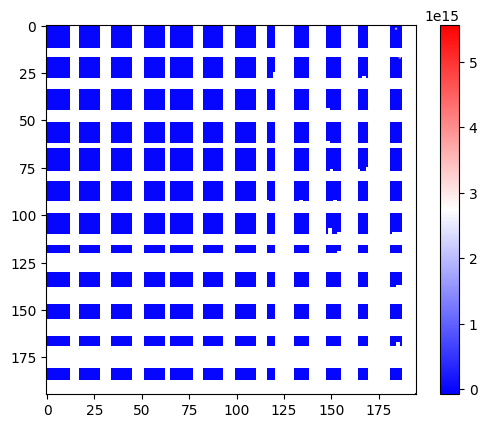

In [45]:
L_ch_inv_MGLensing = np.loadtxt("/home/c2042999/MGLensing/ini_files/pca/Cholesky_inv.txt")
plt.imshow(L_ch_inv_MGLensing/L_choleski_inv, origin='upper',  cmap='bwr')
plt.colorbar()
plt.show()
